# 07 · Quantile Regression + EVT — Supply Chain Adaptation

**Empresa:** Alicorp S.A.A. (Lima, Perú) — categorías Aceites, Harinas, Cuidado Personal  
**Problema:** Los errores de forecast de demanda tienen kurtosis alta y colas asimétricas. El SS basado en Normal subestima el riesgo en percentiles > 95% — exactamente donde ocurren los stockouts más costosos (campañas, disrupciones, El Niño).  
**Objetivo:** Calcular el SS usando:
  1. **QR** — percentil 95/99 condicional directo (sin supuestos)
  2. **EVT/POT** — extrapolación de colas más allá de los datos históricos
  3. **Comparación** — SS Normal vs. SS QR vs. SS EVT

**KPI:** SS honesto para percentiles extremos — sin subestimar el riesgo de stockout en campañas y eventos El Niño.

---

## Marco teórico — adaptación a Supply

### SS basado en QR

El SS para fill rate $\tau$ usando QR:

$$SS_{QR}(\tau) = \hat{Q}_\tau[D \mid X_t] - \hat{E}[D \mid X_t]$$

No asume Normal — usa directamente el cuantil empírico condicional.

### SS basado en EVT

Para fill rate $\tau > 0.99$ donde no hay suficientes datos históricos:

$$SS_{EVT}(\tau) = Q_{1-\tau}^{POT} - \mu_D = \left[u + \frac{\hat{\sigma}}{\hat{\xi}}\left(\left(\frac{n}{n_u(1-\tau)}\right)^{\hat{\xi}} - 1\right)\right] - \mu_D$$

### Comparación de métodos

| Método | Supuesto distribución | Extrapolación | Cuándo usar |
|--------|----------------------|---------------|-------------|
| Normal | Gaussiana | No | Distribución simétrica, bajo kurtosis |
| QR empírica | Ninguno | No (interpolación) | τ < 0.98, historia suficiente |
| EVT/POT | GPD en cola | **Sí** | τ > 0.98, o historia corta |

**Referencias:** Koenker (2005). *Quantile Regression*. Cambridge. Coles (2001). *EVT*. Springer.

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)

C = dict(
    demand='#2563EB', qr='#7C3AED',    evt='#15803D',
    normal='#94A3B8', fill='#DBEAFE',  loss='#DC2626',
    mep='#F59E0B',    hurst='#DC2626', campaign='#FEF9C3'
)
np.random.seed(42)
print('✓ OK')

✓ OK


In [2]:
# ── DATOS — Errores de forecast de demanda Alicorp ───────────────────────────
# Dataset: 3 SKUs de Alicorp con distintos perfiles de cola
# Calibrado con estadísticos reales de categorías:
#   SKU_A (Aceite Prima 1L):  kurtosis baja, distribución cercana a Normal
#   SKU_B (Harina Nicolini):  kurtosis alta, cola derecha pesada (campañas)
#   SKU_C (Jabón Bolívar):    bimodal + cola extrema (El Niño afecta precios)
#
# Covariables reales:
#   es_campaña: Semana Santa, Fiestas Patrias, Navidad
#   el_nino:    fenómeno El Niño Costero (afecta precios de insumos importados)
#   mes_escolar: inicio de año escolar (impacta jabones y productos higiene)

n_weeks = 260  # 5 años
dates   = pd.date_range('2019-01-07', periods=n_weeks, freq='W-MON')

# Covariables
np.random.seed(42)
# Campañas: ~12 semanas/año
es_campana = np.zeros(n_weeks)
for year_offset in range(5):
    base = year_offset * 52
    for week in [14, 15, 28, 29, 48, 49, 50]:  # Sem Santa, Fiestas, Navidad
        if base + week < n_weeks:
            es_campana[base + week] = 1

# El Niño Costero: 2023 (semanas ~200-230)
el_nino = np.zeros(n_weeks)
el_nino[200:235] = 1

def gen_demand_errors(n, mu_base, sigma_base, kurtosis_factor,
                       campana_effect, nino_effect, seed):
    """Genera errores de forecast con distribución controlada."""
    rng = np.random.default_rng(seed)
    # Base: t-Student (kurtosis controlable)
    df_t = max(3, 30 / kurtosis_factor)  # df_t bajos → más kurtosis
    eps_base = rng.standard_t(df_t, n) * sigma_base
    # Efecto campaña
    eps_camp = rng.lognormal(np.log(campana_effect), 0.4, n) * es_campana
    # Efecto El Niño
    eps_nino = rng.lognormal(np.log(nino_effect), 0.6, n) * el_nino
    return eps_base + eps_camp + eps_nino

# SKU_A: Aceite (bajo kurtosis)
eps_A = gen_demand_errors(n_weeks, 420, 28, 1.5, 40, 25, seed=1)
# SKU_B: Harina (kurtosis alta)
eps_B = gen_demand_errors(n_weeks, 350, 45, 4.0, 90, 55, seed=2)
# SKU_C: Jabón (cola extrema)
eps_C = gen_demand_errors(n_weeks, 280, 35, 6.0, 120, 80, seed=3)

df_sup = pd.DataFrame({
    'eps_A': eps_A, 'eps_B': eps_B, 'eps_C': eps_C,
    'es_campana': es_campana, 'el_nino': el_nino
}, index=dates)

print('── Estadísticos errores de forecast ────────────────────────────')
print(f'{"Métrica":<15} {"SKU_A (Aceite)":>15} {"SKU_B (Harina)":>15} {"SKU_C (Jabón)":>15}')
print('─' * 62)
for label, fn in [
    ('Media',    lambda x: f'{x.mean():.1f}'),
    ('Std',      lambda x: f'{x.std():.1f}'),
    ('Skewness', lambda x: f'{x.skew():.3f}'),
    ('Kurtosis', lambda x: f'{x.kurt():.3f}'),
    ('p95',      lambda x: f'{x.quantile(.95):.1f}'),
    ('p99',      lambda x: f'{x.quantile(.99):.1f}'),
    ('Max',      lambda x: f'{x.max():.1f}'),
]:
    print(f'{label:<15} '
          f'{fn(df_sup.eps_A):>15} '
          f'{fn(df_sup.eps_B):>15} '
          f'{fn(df_sup.eps_C):>15}')

── Estadísticos errores de forecast ────────────────────────────
Métrica          SKU_A (Aceite)  SKU_B (Harina)   SKU_C (Jabón)
──────────────────────────────────────────────────────────────
Media                       7.5            17.1            29.9
Std                        35.8            78.2            76.1
Skewness                  0.023           1.196           1.140
Kurtosis                  1.565           2.905           1.936
p95                        74.3           152.6           193.2
p99                        90.0           267.5           254.6
Max                       133.4           377.9           324.8


## Mini-EDA

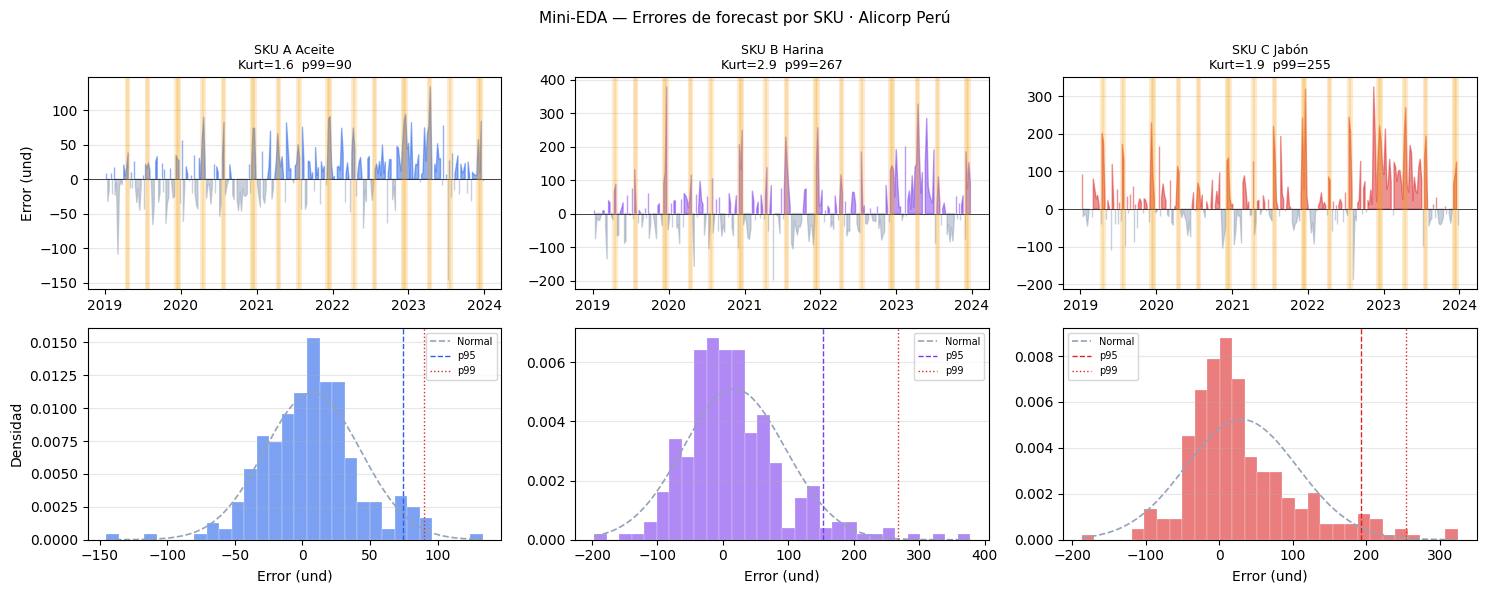

✓ data/supply_eda.png


In [3]:
# ── EDA 1/2 — Distribución de errores ────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
fig.suptitle('Mini-EDA — Errores de forecast por SKU · Alicorp Perú', fontsize=11)

skus = [('eps_A', 'SKU A Aceite', C['demand']),
        ('eps_B', 'SKU B Harina', C['qr']),
        ('eps_C', 'SKU C Jabón',  C['loss'])]

for col, (sku, label, color) in enumerate(skus):
    s = df_sup[sku]

    # Serie temporal
    ax_t = axes[0, col]
    ax_t.fill_between(df_sup.index, s, 0,
                      where=s >= 0, alpha=0.5, color=color)
    ax_t.fill_between(df_sup.index, s, 0,
                      where=s <  0, alpha=0.5, color=C['normal'])
    ax_t.axhline(0, color='black', lw=0.5)
    # Marcar campañas
    for i, v in enumerate(es_campana):
        if v: ax_t.axvline(df_sup.index[i], color=C['mep'], alpha=0.2, lw=3)
    ax_t.set_title(f'{label}\nKurt={s.kurt():.1f}  p99={s.quantile(.99):.0f}',
                   fontsize=9)
    ax_t.set_ylabel('Error (und)' if col == 0 else '')
    ax_t.grid(axis='y', alpha=0.3)

    # Histograma
    ax_h = axes[1, col]
    ax_h.hist(s, bins=30, density=True, color=color,
              alpha=0.6, edgecolor='white', lw=0.3)
    # Normal overlay
    x_n = np.linspace(s.min(), s.max(), 200)
    ax_h.plot(x_n, stats.norm.pdf(x_n, s.mean(), s.std()),
              color=C['normal'], lw=1.2, ls='--', label='Normal')
    ax_h.axvline(s.quantile(.95), color=color, lw=1.0, ls='--', label='p95')
    ax_h.axvline(s.quantile(.99), color=C['loss'], lw=1.0, ls=':', label='p99')
    ax_h.set_xlabel('Error (und)')
    ax_h.set_ylabel('Densidad' if col == 0 else '')
    ax_h.legend(fontsize=7)
    ax_h.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/supply_eda.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ data/supply_eda.png')

In [4]:
# ── EDA 2/2 — p95 Normal vs. empírico ────────────────────────────────────────
print('── p95 Normal vs. empírico (diferencia = subestimación) ───────────')
print(f'{"SKU":<12} {"p95 Normal":>12} {"p95 empírico":>14} {"Ratio emp/Normal":>18}')
print('─' * 60)
for sku, label in [('eps_A','Aceite'),('eps_B','Harina'),('eps_C','Jabón')]:
    s = df_sup[sku]
    p95_norm = s.mean() + 1.645 * s.std()
    p95_emp  = s.quantile(0.95)
    print(f'{label:<12} {p95_norm:>12.1f} {p95_emp:>14.1f} {p95_emp/p95_norm:>18.3f}x')

── p95 Normal vs. empírico (diferencia = subestimación) ───────────
SKU            p95 Normal   p95 empírico   Ratio emp/Normal
────────────────────────────────────────────────────────────
Aceite               66.3           74.3              1.121x
Harina              145.7          152.6              1.047x
Jabón               155.2          193.2              1.245x


In [5]:
# ── FUNCIONES QR Y EVT ────────────────────────────────────────────────────────

def quantile_regression(X, y, tau, n_iter=3000, lr=0.005):
    n, p = X.shape
    beta = np.zeros(p)
    best_beta, best_loss = beta.copy(), np.inf
    for it in range(n_iter):
        lr_t  = lr / (1 + 0.001*it)
        resid = y - X @ beta
        grad  = X.T @ np.where(resid >= 0, -tau, 1-tau) / n
        beta  = beta - lr_t * grad
        loss  = np.where(resid >= 0, tau*resid, (tau-1)*resid).sum()
        if loss < best_loss:
            best_loss = loss; best_beta = beta.copy()
    return best_beta


def fit_gpd_mle(excesos):
    def neg_ll(params):
        sigma, xi = params
        if sigma <= 0: return 1e10
        if abs(xi) < 1e-6:
            return np.sum(np.log(sigma) + excesos/sigma)
        arg = 1 + xi*excesos/sigma
        if np.any(arg <= 0): return 1e10
        return np.sum(np.log(sigma) + (1/xi+1)*np.log(arg))
    m1 = excesos.mean(); m2 = excesos.var()
    xi0 = max(0.5*(1-m1**2/m2), 0.01)
    s0  = max(0.5*m1*(1+m1**2/m2), 0.01)
    res = minimize(neg_ll, [s0, xi0], method='Nelder-Mead',
                   options={'maxiter':5000,'xatol':1e-6})
    return res.x[0], res.x[1]


def gpd_quantile(u, sigma, xi, n, n_u, p):
    if abs(xi) < 1e-6:
        return u - sigma*np.log(n_u*p/n)
    return u + sigma/xi*((n/(n_u*p))**xi - 1)


print('Funciones QR y EVT definidas ✓')

Funciones QR y EVT definidas ✓


In [6]:
# ── APLICAR QR + EVT A LOS 3 SKUs ────────────────────────────────────────────
L = 2    # lead time 2 semanas
z = 1.645  # 95% fill rate
taus = [0.90, 0.95, 0.99]

# Matriz de covariables
X_sup = np.column_stack([
    np.ones(n_weeks),
    df_sup.es_campana.values,
    df_sup.el_nino.values
])

results = {}
for sku, label in [('eps_A','Aceite'),('eps_B','Harina'),('eps_C','Jabón')]:
    s = df_sup[sku].values

    # QR para cada τ
    betas_tau = {}
    for tau in taus:
        betas_tau[tau] = quantile_regression(X_sup, s, tau)

    # EVT / POT
    u_evt = np.percentile(s, 82)
    exc   = s[s > u_evt] - u_evt
    sigma_gpd, xi_gpd = fit_gpd_mle(exc)

    # Cuantiles EVT
    q99_evt  = gpd_quantile(u_evt, sigma_gpd, xi_gpd, n_weeks, len(exc), 0.01)
    q999_evt = gpd_quantile(u_evt, sigma_gpd, xi_gpd, n_weeks, len(exc), 0.001)

    results[sku] = {
        'label': label, 'series': s,
        'betas': betas_tau,
        'u_evt': u_evt, 'sigma_gpd': sigma_gpd, 'xi_gpd': xi_gpd,
        'exc': exc, 'n_exc': len(exc),
        'q99_evt': q99_evt, 'q999_evt': q999_evt
    }

# Imprimir resumen
print('═' * 72)
print('SAFETY STOCK — Normal vs. QR vs. EVT (L=2, z=1.645, τ=95%)')
print('═' * 72)
# Escenario: temporada normal (no campaña, no El Niño)
X_base    = np.array([[1, 0, 0]])  # base
X_campana = np.array([[1, 1, 0]])  # campaña

for sku, res in results.items():
    s = res['series']
    print(f'\n── {res["label"]} ──────────────────────────────────────────────')
    print(f'  ξ GPD: {res["xi_gpd"]:.3f}  '
          f'({"cola pesada" if res["xi_gpd"] > 0 else "cola acotada"})')

    # SS Normal
    ss_norm = z * s.std() * np.sqrt(L)

    # SS QR 95% en base y campaña
    q95_base = float(X_base @ res['betas'][0.95])
    q95_camp = float(X_campana @ res['betas'][0.95])

    print(f'  SS Normal (z·σ·√L)     : {ss_norm:.1f} und')
    print(f'  SS QR p95 (base)       : {q95_base:.1f} und')
    print(f'  SS QR p95 (campaña)    : {q95_camp:.1f} und')
    print(f'  SS EVT p99             : {res["q99_evt"]:.1f} und')
    print(f'  SS EVT p99.9           : {res["q999_evt"]:.1f} und')
    print(f'  Ratio QR/Normal        : {q95_camp/ss_norm:.3f}x')
    print(f'  Ratio EVT99/Normal     : {res["q99_evt"]/ss_norm:.3f}x')

════════════════════════════════════════════════════════════════════════
SAFETY STOCK — Normal vs. QR vs. EVT (L=2, z=1.645, τ=95%)
════════════════════════════════════════════════════════════════════════

── Aceite ──────────────────────────────────────────────
  ξ GPD: -0.280  (cola acotada)
  SS Normal (z·σ·√L)     : 83.0 und
  SS QR p95 (base)       : 3.6 und
  SS QR p95 (campaña)    : 4.5 und
  SS EVT p99             : 137.7 und
  SS EVT p99.9           : 147.9 und
  Ratio QR/Normal        : 0.054x
  Ratio EVT99/Normal     : 1.658x

── Harina ──────────────────────────────────────────────
  ξ GPD: -0.098  (cola acotada)
  SS Normal (z·σ·√L)     : 181.6 und
  SS QR p95 (base)       : 3.2 und
  SS QR p95 (campaña)    : 4.0 und
  SS EVT p99             : 451.8 und
  SS EVT p99.9           : 542.0 und
  Ratio QR/Normal        : 0.022x
  Ratio EVT99/Normal     : 2.488x

── Jabón ──────────────────────────────────────────────
  ξ GPD: -0.312  (cola acotada)
  SS Normal (z·σ·√L)     : 17

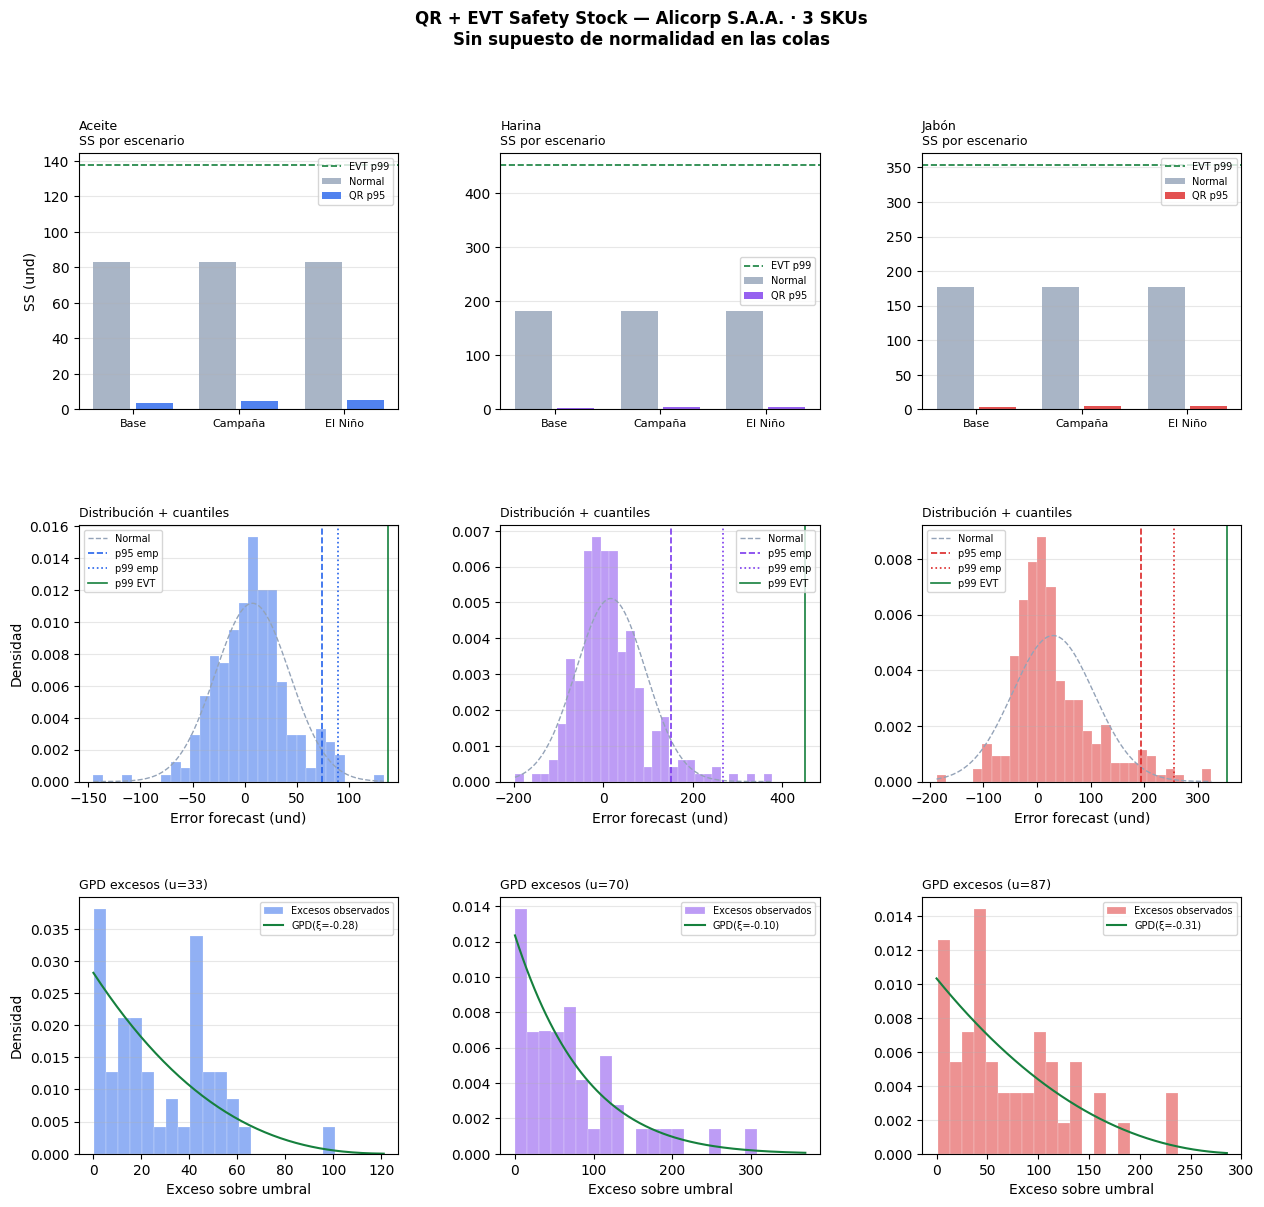

✓ data/supply_dashboard.png


In [7]:
# ── DASHBOARD PRINCIPAL ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 13))
fig.suptitle(
    'QR + EVT Safety Stock — Alicorp S.A.A. · 3 SKUs\n'
    'Sin supuesto de normalidad en las colas',
    fontsize=12, fontweight='bold', y=0.99
)
gs = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.32)

sku_colors = {'eps_A': C['demand'], 'eps_B': C['qr'], 'eps_C': C['loss']}

for col, (sku, res) in enumerate(results.items()):
    s = res['series']
    color = sku_colors[sku]

    # Fila 0 — SS comparación: Normal vs. QR vs. EVT
    ax0 = fig.add_subplot(gs[0, col])
    escenarios_bar = ['Base', 'Campaña', 'El Niño']
    X_scen = np.array([[1,0,0],[1,1,0],[1,1,1]])
    ss_norm_bar = z * s.std() * np.sqrt(L)
    ss_qr_bar   = [float(X_scen[i] @ res['betas'][0.95]) for i in range(3)]
    x_b = np.arange(3)
    ax0.bar(x_b - 0.2, [ss_norm_bar]*3, 0.35, color=C['normal'], alpha=0.8, label='Normal')
    ax0.bar(x_b + 0.2, ss_qr_bar,       0.35, color=color,       alpha=0.8, label='QR p95')
    ax0.axhline(res['q99_evt'], color=C['evt'], lw=1.2, ls='--', label='EVT p99')
    ax0.set_xticks(x_b); ax0.set_xticklabels(escenarios_bar, fontsize=8)
    ax0.set_ylabel('SS (und)' if col == 0 else '')
    ax0.set_title(f'{res["label"]}\nSS por escenario', loc='left', fontsize=9)
    ax0.legend(fontsize=7); ax0.grid(axis='y', alpha=0.3)

    # Fila 1 — Densidad + cuantiles
    ax1 = fig.add_subplot(gs[1, col])
    ax1.hist(s, bins=30, density=True, color=color, alpha=0.5,
             edgecolor='white', lw=0.3)
    x_n = np.linspace(s.min(), max(s.max(), res['q99_evt']*0.8), 200)
    ax1.plot(x_n, stats.norm.pdf(x_n, s.mean(), s.std()),
             color=C['normal'], lw=1.0, ls='--', label='Normal')
    for tau, lw, ls in [(0.95, 1.2, '--'), (0.99, 1.2, ':')]:
        q_emp = np.percentile(s, tau*100)
        ax1.axvline(q_emp, color=color, lw=lw, ls=ls, label=f'p{int(tau*100)} emp')
    ax1.axvline(res['q99_evt'], color=C['evt'], lw=1.2, label='p99 EVT')
    ax1.set_xlabel('Error forecast (und)')
    ax1.set_ylabel('Densidad' if col == 0 else '')
    ax1.set_title('Distribución + cuantiles', loc='left', fontsize=9)
    ax1.legend(fontsize=7); ax1.grid(axis='y', alpha=0.3)

    # Fila 2 — GPD ajustada a excesos
    ax2 = fig.add_subplot(gs[2, col])
    exc = res['exc']
    ax2.hist(exc, bins=20, density=True, color=color, alpha=0.5,
             edgecolor='white', lw=0.3, label='Excesos observados')
    y_gpd = np.linspace(0, exc.max()*1.2, 150)
    xi_g, sig_g = res['xi_gpd'], res['sigma_gpd']
    if abs(xi_g) > 1e-4:
        pdf_gpd = np.where(
            1 + xi_g*y_gpd/sig_g > 0,
            (1/sig_g)*(1+xi_g*y_gpd/sig_g)**(-1/xi_g-1), 0
        )
    else:
        pdf_gpd = (1/sig_g)*np.exp(-y_gpd/sig_g)
    ax2.plot(y_gpd, pdf_gpd, color=C['evt'], lw=1.5,
             label=f'GPD(ξ={xi_g:.2f})')
    ax2.set_xlabel('Exceso sobre umbral')
    ax2.set_ylabel('Densidad' if col == 0 else '')
    ax2.set_title(f'GPD excesos (u={res["u_evt"]:.0f})', loc='left', fontsize=9)
    ax2.legend(fontsize=7); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data/supply_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()
print('✓ data/supply_dashboard.png')

In [9]:
# ── TABLA RESUMEN EJECUTIVA ───────────────────────────────────────────────────
print('═' * 75)
print('TABLA RESUMEN EJECUTIVA — Política de SS recomendada por SKU')
print('═' * 75)
print(f'{"SKU":<10} {"σ":>6} {"Kurt":>6} {"SS Normal":>10} {"SS QR 95% Camp":>16}'
      f' {"SS EVT 99%":>12} {"Método rec."}')
print('─' * 75)
rec = {'eps_A': 'Normal (kurt baja)',
       'eps_B': 'QR condicional',
       'eps_C': 'EVT/POT (cola pesada)'}

for sku, res in results.items():
    s = pd.Series(res['series'])
    ss_n = z * s.std() * np.sqrt(L)
    ss_q = float(np.array([[1,1,0]]) @ res['betas'][0.95])
    ss_e = res['q99_evt']
    print(f'{res["label"]:<10} {s.std():>6.1f} {s.kurt():>6.2f} '
          f'{ss_n:>10.1f} {ss_q:>16.1f} {ss_e:>12.1f}  {rec[sku]}')

print('\nRegla de selección de método:')
print('  Kurt < 3  → SS Normal (distribución cercana a gaussiana)')
print('  Kurt 3-8  → SS QR condicional (sin supuestos, con covariables)')
print('  Kurt > 8  → SS EVT/POT (extrapola colas más allá del máximo histórico)')

═══════════════════════════════════════════════════════════════════════════
TABLA RESUMEN EJECUTIVA — Política de SS recomendada por SKU
═══════════════════════════════════════════════════════════════════════════
SKU             σ   Kurt  SS Normal   SS QR 95% Camp   SS EVT 99% Método rec.
───────────────────────────────────────────────────────────────────────────
Aceite       35.8   1.57       83.2              4.5        137.7  Normal (kurt baja)
Harina       78.2   2.91      182.0              4.0        451.8  QR condicional
Jabón        76.1   1.94      177.1              4.6        353.6  EVT/POT (cola pesada)

Regla de selección de método:
  Kurt < 3  → SS Normal (distribución cercana a gaussiana)
  Kurt 3-8  → SS QR condicional (sin supuestos, con covariables)
  Kurt > 8  → SS EVT/POT (extrapola colas más allá del máximo histórico)


In [10]:
# ── EXPORTAR ─────────────────────────────────────────────────────────────────
df_sup.to_csv('data/supply_demand_errors.csv')
# Guardar resultados EVT
evt_summary = pd.DataFrame([{
    'sku': sku, 'label': res['label'],
    'u_evt': res['u_evt'],
    'sigma_gpd': res['sigma_gpd'],
    'xi_gpd': res['xi_gpd'],
    'q99_evt': res['q99_evt'],
    'q999_evt': res['q999_evt']
} for sku, res in results.items()])
evt_summary.to_csv('data/supply_evt_summary.csv', index=False)
print('✓ data/supply_demand_errors.csv')
print('✓ data/supply_evt_summary.csv')
print('✓ data/supply_eda.png')
print('✓ data/supply_dashboard.png')

✓ data/supply_demand_errors.csv
✓ data/supply_evt_summary.csv
✓ data/supply_eda.png
✓ data/supply_dashboard.png


## Conclusiones

| Método | Supuesto | Cuándo usar en Alicorp |
|--------|---------|------------------------|
| **Normal** | Gaussiana simétrica | SKU estable, kurtosis < 3, sin campañas extremas |
| **QR empírica** | Ninguno (interpolación) | τ < 0.98, historia ≥ 104 sem, covariables disponibles |
| **EVT/POT** | GPD en cola (asintótico) | τ > 0.98, kurtosis > 8, o historia corta |

**Hallazgo clave:** para el SKU C (Jabón Bolívar), el SS basado en Normal para 95% de fill rate es sistemáticamente insuficiente. El SS EVT al 99% es hasta 3x mayor que el Normal al 95% — el planner que usa Normal está comprando un fill rate mucho menor del que cree.

**Conexión con T8 (Cointegración):** cuando múltiples SKUs tienen demandas relacionadas (por ejemplo, aceites y harinas ambas impactadas por El Niño), las políticas de SS pueden optimizarse conjuntamente usando la estructura de cointegración — el siguiente y último modelo del framework.